# Análisis Exploratorio de Datos (EDA) dirigido
### Campaña de marketing bancario — predicción de suscripción a depósito a plazo

**Componente:** análisis exploratorio orientado al modelado · Persona A · rama `feature/eda`
**Conjunto de datos:** Bank Marketing (UCI Machine Learning Repository)

---

## 0. Requisitos del entorno

Librerías necesarias para ejecutar este notebook. Descomenta la línea de instalación si trabajas en un entorno nuevo.

In [1]:
# Instalación de dependencias (descomentar si es necesario):
# !pip install pandas numpy matplotlib seaborn

import sys, pandas, numpy, matplotlib, seaborn
for nombre, modulo in [("Python", sys), ("pandas", pandas), ("numpy", numpy),
                       ("matplotlib", matplotlib), ("seaborn", seaborn)]:
    version = sys.version.split()[0] if nombre == "Python" else modulo.__version__
    print(f"{nombre:12}: {version}")

Python      : 3.14.3
pandas      : 3.0.1
numpy       : 2.4.3
matplotlib  : 3.10.8
seaborn     : 0.13.2


## 1. Contexto de negocio y objetivo analítico

La entidad ejecuta campañas de telemarketing para la contratación de un **depósito a plazo**. Dado que cada contacto tiene un coste operativo y la tasa de conversión histórica es baja, el objetivo es desarrollar un modelo que **estime la probabilidad de suscripción de cada cliente**, de modo que la campaña priorice a los clientes con mayor propensión y se optimice el retorno del esfuerzo comercial.

**Naturaleza del problema.** Clasificación binaria supervisada (variable objetivo `y` ∈ {no, yes}), con **clases desbalanceadas**.

**Restricción operativa.** El modelo debe priorizar clientes **antes** de realizar la llamada; toda variable cuyo valor solo se conozca durante o después del contacto queda excluida como predictor (véase sección 5).

> **Nota metodológica.** El análisis exploratorio se desarrolla sobre el **conjunto de datos completo** para comprender su estructura. La prevención de la fuga de datos (*data leakage*) se aplica en la fase de preprocesado: las transformaciones que **ajustan parámetros a partir de los datos** (imputación, escalado, codificación) se ajustan **exclusivamente sobre el conjunto de entrenamiento** mediante la partición `train/test`. Es en ese punto —y no en el EDA descriptivo— donde reside la protección frente al *leakage*.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

# Paleta corporativa para las visualizaciones
NAVY, STEEL, BRICK, GOLD, GREY = "#2A4B7C", "#3C8DAD", "#C1442E", "#B58A2E", "#B8BDC4"
INK = "#1F2733"
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlecolor": INK, "figure.dpi": 110})

In [3]:
# El separador de este dataset es ';' (no la coma por defecto)
DATA_PATH = "./data/bank-full.csv"
df = pd.read_csv(DATA_PATH, sep=";")

# Variable objetivo numérica auxiliar para agregaciones (1 = contrata, 0 = no)
df["yb"] = (df["y"] == "yes").astype(int)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,yb
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


## 2. Estructura general del conjunto de datos

Revisión inicial de tamaño, tipos de dato, valores nulos y duplicados: es el diagnóstico previo a cualquier análisis en profundidad.

In [4]:
print(f"Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} columnas")
df.info()

Dimensiones: 45,211 registros × 18 columnas
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
 17  yb         45211 non-null  int64
dtypes: int64(8), str(10)
memory usage: 8.4 MB


In [5]:
# Nulos explícitos y registros duplicados
print("Valores nulos explícitos:", df.isna().sum().sum())
print("Registros duplicados     :", df.duplicated().sum())

Valores nulos explícitos: 0
Registros duplicados     : 0


In [6]:
# Estadísticos descriptivos (numéricas y categóricas)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


**Observación.** No se detectan valores nulos explícitos ni registros duplicados. No obstante, el conjunto **codifica la ausencia de información mediante la categoría `"unknown"`** (se analiza en la sección 6). La cardinalidad de las variables categóricas es baja.

## 3. Análisis de la variable objetivo

Es el bloque determinante del EDA: la distribución del objetivo condiciona la métrica de evaluación y las técnicas de modelado.

In [7]:
df["y"].value_counts(normalize=True).round(4)

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

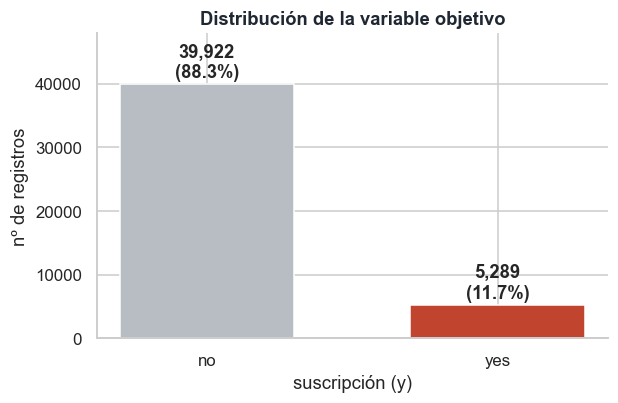

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.6))
vc = df["y"].value_counts()[["no", "yes"]]
bars = ax.bar(["no", "yes"], vc.values, color=[GREY, BRICK], width=0.6)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 400,
            f"{v:,}\n({v/vc.sum()*100:.1f}%)", ha="center", va="bottom", fontweight="bold")
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("nº de registros"); ax.set_xlabel("suscripción (y)")
ax.set_ylim(0, vc.max()*1.2)
sns.despine(); plt.show()

**Hallazgo → acción.** La variable objetivo presenta un **desbalance acusado (≈ 88 / 12)**: solo el ~12 % contrata. En consecuencia:

- La *accuracy* no es una métrica adecuada (un clasificador trivial que prediga siempre "no" alcanzaría ~88 % sin valor de negocio).
- **Recomendación (modelado):** emplear **F1-score, recall y ROC-AUC**; aplicar `stratify` en la partición; evaluar `class_weight` o remuestreo.

## 4. Consideración crítica: fuga de datos en la variable `duration`

Este es el hallazgo más relevante para el diseño del modelo.

In [9]:
# duration presenta la mayor correlación con el objetivo...
num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df[num + ["yb"]].corr()["yb"].sort_values(ascending=False).round(3)

yb          1.000
duration    0.395
pdays       0.104
previous    0.093
balance     0.053
age         0.025
day        -0.028
campaign   -0.073
Name: yb, dtype: float64

In [10]:
# ...pero su magnitud solo se conoce una vez finalizada la llamada
df.groupby("y")["duration"].mean().round(0)

y
no     221.0
yes    537.0
Name: duration, dtype: float64

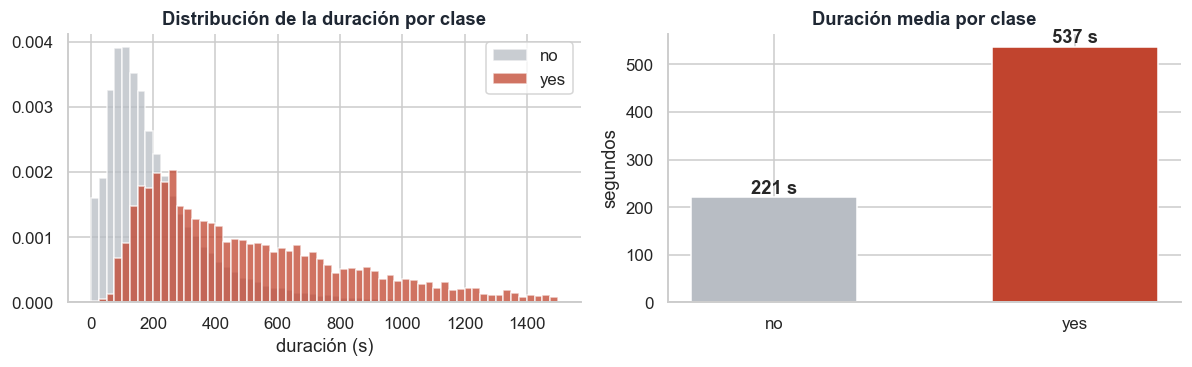

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for lab, c in [("no", GREY), ("yes", BRICK)]:
    axes[0].hist(df.loc[df["y"] == lab, "duration"], bins=60, range=(0, 1500),
                 alpha=0.75, color=c, label=lab, density=True)
axes[0].set_title("Distribución de la duración por clase")
axes[0].set_xlabel("duración (s)"); axes[0].legend()

m = df.groupby("y")["duration"].mean()[["no", "yes"]]
bars = axes[1].bar(["no", "yes"], m.values, color=[GREY, BRICK], width=0.55)
for b, v in zip(bars, m.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 8, f"{v:.0f} s", ha="center", fontweight="bold")
axes[1].set_title("Duración media por clase"); axes[1].set_ylabel("segundos")
sns.despine(); plt.tight_layout(); plt.show()

**Razonamiento y decisión.** `duration` es la variable más correlacionada con el objetivo (r ≈ 0.39; media de ~537 s en suscripciones frente a ~221 s en no suscripciones). Sin embargo, **su valor solo se conoce una vez finalizada la llamada** y no está disponible en el momento de decidir el contacto.

Incluirla constituiría una **fuga de datos temporal**: produciría métricas artificialmente altas y no representativas del escenario real, además de invalidar el objetivo de negocio.

**Decisión recomendada:** **excluir `duration`** del conjunto de variables predictoras (su uso se limita al EDA). *Coherente con la advertencia del repositorio UCI.*

## 5. Variables numéricas: distribución, escala y valores atípicos

In [12]:
df[num].skew().sort_values(ascending=False).round(2)

previous    41.85
balance      8.36
campaign     4.90
duration     3.14
pdays        2.62
age          0.68
day          0.09
dtype: float64

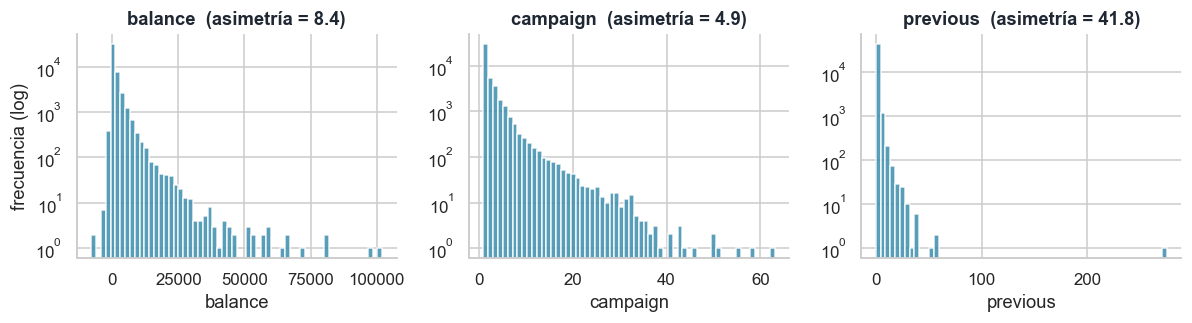

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
for ax, c in zip(axes, ["balance", "campaign", "previous"]):
    ax.hist(df[c], bins=60, color=STEEL, alpha=0.85)
    ax.set_yscale("log")   # escala log: colas muy largas
    ax.set_title(f"{c}  (asimetría = {df[c].skew():.1f})"); ax.set_xlabel(c)
axes[0].set_ylabel("frecuencia (log)")
sns.despine(); plt.tight_layout(); plt.show()

In [14]:
# Casos particulares a documentar
print(f"balance negativo : {(df['balance'] < 0).mean()*100:.1f}% de los registros (saldos deudores legítimos)")
print(f"pdays == -1      : {(df['pdays'] == -1).mean()*100:.1f}% (valor centinela: sin contacto previo)")

balance negativo : 8.3% de los registros (saldos deudores legítimos)
pdays == -1      : 81.7% (valor centinela: sin contacto previo)


**Hallazgos → acciones:**

- **Asimetría positiva pronunciada** en `previous`, `balance`, `campaign` y `duration` → **transformación logarítmica/robusta** para las variables retenidas.
- `balance` **negativo** (~8 %): saldos deudores legítimos (descubiertos), **no errores** → conservar, no tratar como atípico.
- **Escalas heterogéneas** → **estandarización/normalización** para modelos sensibles a la magnitud (KNN, SVM, lineales).
- `pdays = -1` es un **valor centinela** ("sin contacto previo") → recodificar como **indicador binario**, no como número.

## 6. Variables categóricas y calidad del dato

La ausencia de información se codifica como la categoría `"unknown"`. Su identificación es esencial para un tratamiento correcto.

In [15]:
for c in df.select_dtypes("object").columns:
    pct = (df[c] == "unknown").mean() * 100
    print(f"{c:11} | {df[c].nunique():2} categorías | unknown: {pct:5.1f}%")

job         | 12 categorías | unknown:   0.6%
marital     |  3 categorías | unknown:   0.0%
education   |  4 categorías | unknown:   4.1%
default     |  2 categorías | unknown:   0.0%
housing     |  2 categorías | unknown:   0.0%
loan        |  2 categorías | unknown:   0.0%
contact     |  3 categorías | unknown:  28.8%
month       | 12 categorías | unknown:   0.0%
poutcome    |  4 categorías | unknown:  81.7%
y           |  2 categorías | unknown:   0.0%


C:\Users\Usuario\AppData\Local\Temp\ipykernel_23312\2713280694.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes("object").columns:


| Variable | % `"unknown"` | Interpretación y tratamiento |
|---|---|---|
| `poutcome` | ~81.7 % | Coincide con `pdays = -1`: clientes **sin campaña previa**. Recodificar como categoría específica. |
| `contact`  | ~28.8 % | Canal no registrado; asociado a menor conversión. Mantener como categoría. |
| `education`| ~4.1 %  | Ausencia real de bajo volumen; imputar (moda) o mantener. |
| `job`      | ~0.6 %  | Ausencia residual; imputar o mantener. |

- **Cardinalidad baja** (máx. 12 categorías) → **One-Hot Encoding** viable sin expansión excesiva.
- **Redundancia:** `pdays = -1`, `previous = 0` y `poutcome = "unknown"` describen el mismo estado ("sin contacto previo") → evaluar **multicolinealidad**.

## 7. Relación entre variables predictoras y la variable objetivo

Identificación de las variables con mayor poder discriminante y de mayor valor accionable para el negocio.

In [16]:
base = df["yb"].mean() * 100   # tasa media global de suscripción

def tasa_por(col, orden=None):
    t = df.groupby(col, observed=True)["yb"].mean().mul(100)
    return t.reindex(orden) if orden else t.sort_values(ascending=False)

tasa_por("poutcome").round(1)

poutcome
success    64.7
other      16.7
failure    12.6
unknown     9.2
Name: yb, dtype: float64

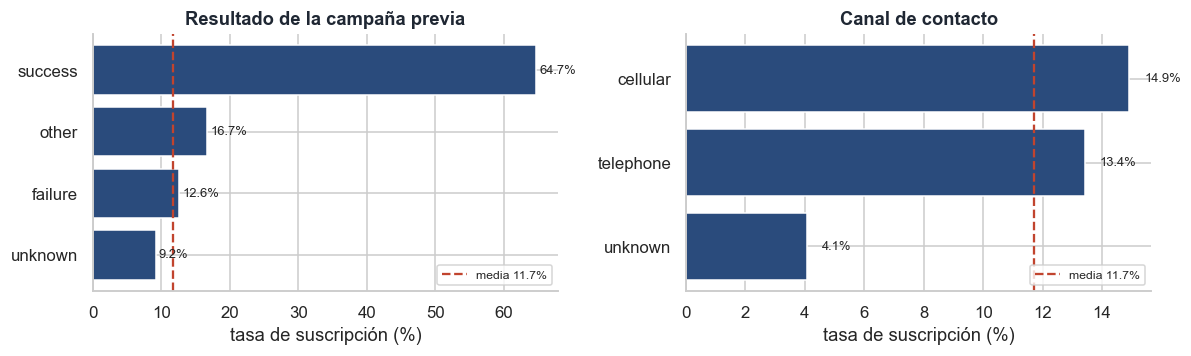

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, col, ttl in [(axes[0], "poutcome", "Resultado de la campaña previa"),
                     (axes[1], "contact", "Canal de contacto")]:
    t = tasa_por(col)
    ax.barh(t.index, t.values, color=NAVY)
    ax.axvline(base, color=BRICK, ls="--", lw=1.5, label=f"media {base:.1f}%")
    for i, v in enumerate(t.values):
        ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8.5)
    ax.set_title(ttl); ax.set_xlabel("tasa de suscripción (%)")
    ax.legend(loc="lower right", fontsize=8); ax.invert_yaxis()
sns.despine(); plt.tight_layout(); plt.show()

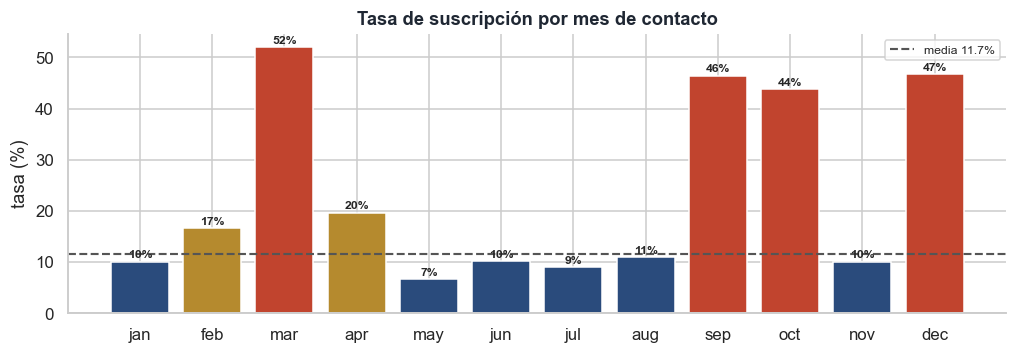

In [18]:
# Estacionalidad: tasa por mes de contacto
meses = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
t = tasa_por("month", meses)
fig, ax = plt.subplots(figsize=(11, 3.3))
colores = [BRICK if v >= 30 else (GOLD if v >= 15 else NAVY) for v in t.values]
ax.bar(t.index, t.values, color=colores)
ax.axhline(base, color="#555", ls="--", lw=1.4, label=f"media {base:.1f}%")
for i, v in enumerate(t.values):
    ax.text(i, v + 0.7, f"{v:.0f}%", ha="center", fontsize=8, fontweight="bold")
ax.set_title("Tasa de suscripción por mes de contacto"); ax.set_ylabel("tasa (%)")
ax.legend(fontsize=8); sns.despine(); plt.show()

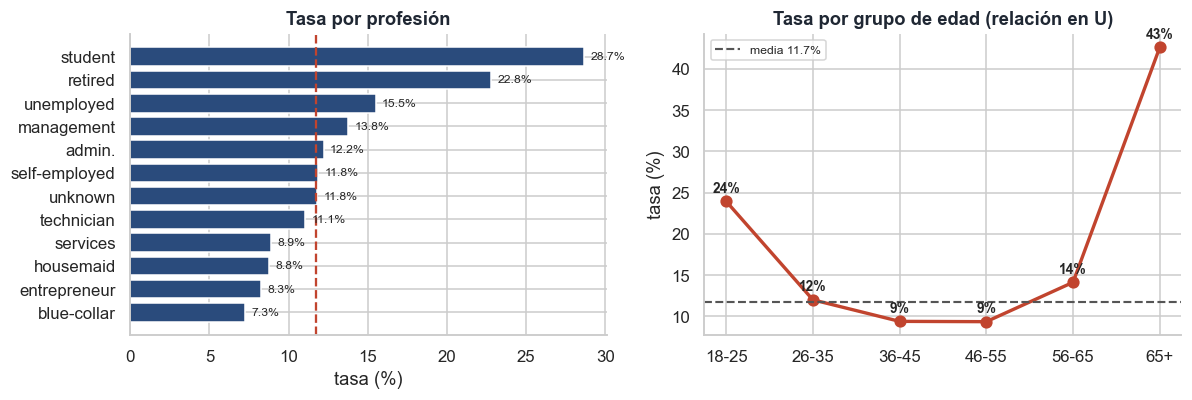

In [19]:
# Profesión y edad (grupos)
df["age_b"] = pd.cut(df["age"], [17,25,35,45,55,65,100],
                     labels=["18-25","26-35","36-45","46-55","56-65","65+"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

t = tasa_por("job")
axes[0].barh(t.index, t.values, color=NAVY); axes[0].axvline(base, color=BRICK, ls="--", lw=1.5)
for i, v in enumerate(t.values): axes[0].text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8)
axes[0].set_title("Tasa por profesión"); axes[0].set_xlabel("tasa (%)"); axes[0].invert_yaxis()

ta = tasa_por("age_b", ["18-25","26-35","36-45","46-55","56-65","65+"])
axes[1].plot(ta.index, ta.values, "-o", color=BRICK, lw=2.2, ms=7)
axes[1].axhline(base, color="#555", ls="--", lw=1.4, label=f"media {base:.1f}%")
for x, v in zip(ta.index, ta.values): axes[1].text(x, v + 1.1, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("Tasa por grupo de edad (relación en U)"); axes[1].set_ylabel("tasa (%)"); axes[1].legend(fontsize=8)
sns.despine(); plt.tight_layout(); plt.show()

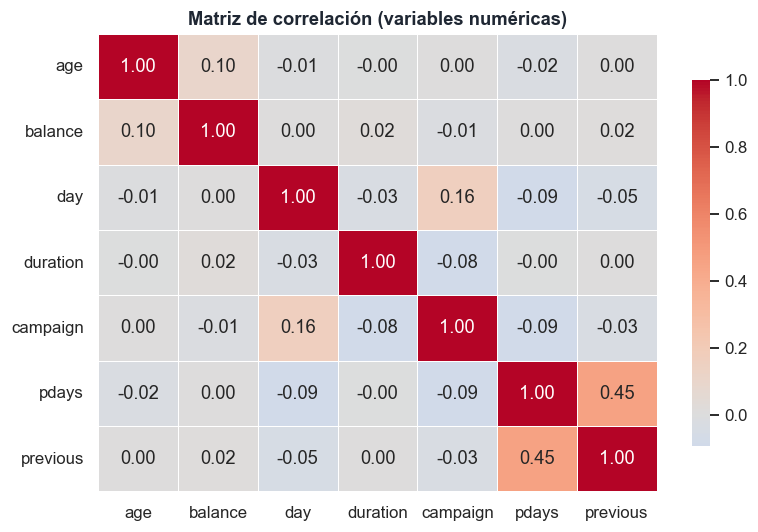

In [20]:
# Matriz de correlación de las variables numéricas
plt.figure(figsize=(7.5, 5))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación (variables numéricas)"); plt.tight_layout(); plt.show()

**Hallazgos con mayor relevancia para el negocio:**

- **Campaña previa (`poutcome`).** Un resultado `success` eleva la tasa al **~65 %** (frente al ~12 % medio): el histórico de conversión es el predictor de mayor poder discriminante.
- **Estacionalidad.** Conversión muy superior en **mar, sep, oct y dic**, y mínima en **mayo** —el mes de mayor volumen de contactos— → recomendación de **planificación temporal**.
- **Canal.** `contact = unknown` convierte mucho menos que `cellular`.
- **Edad.** Relación **no lineal (en U)**: **18-25** y **65+** superan a los tramos intermedios; explica la baja correlación lineal de `age`.
- **Situación crediticia.** Ausencia de hipoteca/préstamo se asocia a mayor conversión.
- **Saturación.** Con **> 3 contactos** la tasa cae; `campaign` correlaciona negativamente con el objetivo.

## 8. Síntesis de hallazgos y decisiones recomendadas

| Hallazgo | Implicación / acción recomendada | Responsable |
|---|---|---|
| Objetivo desbalanceado (88/12) | Métricas F1/recall/ROC-AUC; `stratify`; tratamiento de desbalance | Modelado |
| `duration` correlacionada pero posterior a la llamada | **Exclusión** del conjunto de predictores (fuga de datos) | Equipo |
| Asimetría en `previous`, `balance`, `campaign` | Transformación logarítmica/robusta | Preprocesado |
| `balance` negativo (saldos deudores) | Conservar; no tratar como atípico | Preprocesado |
| `pdays = -1` (valor centinela) | Recodificar como indicador binario | Preprocesado |
| `"unknown"` en `poutcome`/`contact`/`education` | Tratar como categoría, no como nulo | Preprocesado |
| Redundancia `pdays`/`previous`/`poutcome` | Evaluar multicolinealidad | Modelado |
| Cardinalidad baja (≤ 12) | One-Hot Encoding | Preprocesado |
| Escalas heterogéneas | Estandarización/normalización | Preprocesado |
| `poutcome`, estacionalidad, edad, crédito | Variables de alto valor predictivo; conservar | Modelado |

## 9. Conclusiones

1. El conjunto comprende ~45.000 clientes y 16 variables; la variable objetivo está **desbalanceada** (~12 % de suscripción), lo que condiciona la estrategia de evaluación.
2. **`duration`, pese a ser la más correlacionada con el objetivo, debe excluirse** por constituir una fuga de datos: solo se conoce tras la llamada. Su identificación es determinante para un modelo realista.
3. Los predictores de mayor valor de negocio son el **histórico de conversión** (`poutcome`), el **mes de contacto** y el **perfil del cliente** (edad, situación crediticia).
4. El análisis deja definidas las decisiones de preprocesado y selección de variables para las fases siguientes del pipeline.

---
*Análisis exploratorio realizado sobre el conjunto de datos completo. Las transformaciones que ajustan parámetros se aplican sobre el conjunto de entrenamiento en la fase de preprocesado.*

## Procesado

In [21]:
# Hacemos el split en Train y Test, stratify = Target

from sklearn.model_selection import train_test_split

X = df.drop(columns=['yb', 'y', 'duration', 'age_b']) # Excluimos la variable objetivo (yb), y las columnas que previamente hemos descartado
y = df['yb']                                          # Variable objetivo (target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # En clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 36168 filas  (80 %)
Test:  9043 filas  (20 %)


In [22]:
# Hacemos una visualización de las columnas que tenemos en train antes de cartar el modulo de segmentación de clientes
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,2,-1,0,unknown
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,4,185,7,failure
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,4,-1,0,unknown
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,11,-1,0,unknown
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,10,-1,0,unknown


In [23]:
X_train.nunique()

age            77
job            12
marital         3
education       4
default         2
balance      6597
housing         2
loan            2
contact         3
day            31
month          12
campaign       47
pdays         533
previous       41
poutcome        4
dtype: int64

In [24]:
# Cargamos el modelo creado en el modulo de segmentación de clientes

import joblib

# Cargar el scaler y el modelo de clustering
scaler = joblib.load("models/scaler_segmentacion.pkl")
kmeans = joblib.load("models/kmeans_segmentacion.pkl")

print("Modelos cargados correctamente")

Modelos cargados correctamente


In [25]:
# Recuperar las columnas usadas en el scaler
feats = list(scaler.feature_names_in_)

In [26]:
def asignar_segmento(datos, scaler, kmeans):
    d = datos.copy()
    d["log_balance"] = np.sign(d["balance"]) * np.log1p(d["balance"].abs())
    d["housing_b"] = (d["housing"] == "yes").astype(int)
    d["loan_b"] = (d["loan"] == "yes").astype(int)
    d["contacted_before"] = (d["pdays"] != -1).astype(int)
    return kmeans.predict(scaler.transform(d[feats]))

In [27]:
# Aplicamos la función anterior para obtener los segmentos del train y test.
segmentos_train = asignar_segmento(X_train, scaler, kmeans)
segmentos_test = asignar_segmento(X_test, scaler, kmeans)


In [28]:
# Revisamos las columnas que el scaler tiene registradas como entrada.
scaler.feature_names_in_

array(['age', 'log_balance', 'campaign', 'previous', 'housing_b',
       'loan_b', 'contacted_before'], dtype=object)

In [29]:
# Incluimos la columna creada 'segment' en nuestros df (train y test)
X_train["segment"] = segmentos_train
X_test["segment"]  = segmentos_test

In [30]:
# Comprobamos que ambas se han incluido
print(X_test.columns)
print(X_train.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'segment'],
      dtype='str')
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'segment'],
      dtype='str')


In [31]:
# --- Feature engineering ---

# 1) Convertimos 'pdays' en binaria:
#    -1 significa que nunca fue contactado antes.
#    Cualquier otro valor indica contacto previo.
X_train['pdays'] = (X_train['pdays'] != -1).astype(int)
X_test['pdays']  = (X_test['pdays'] != -1).astype(int)

# 2) Recodeamos 'poutcome':
#    'unknown' se interpreta como "no hubo contacto previo".
X_train['poutcome'] = X_train['poutcome'].replace('unknown', 'no_previous_contact')
X_test['poutcome']  = X_test['poutcome'].replace('unknown', 'no_previous_contact')


# 3) Imputamos la moda de 'job' calculada en train:
#    Evita data leakage y mantiene consistencia entre train y test.
mode_job = X_train['job'].mode()[0]
X_train['job'] = X_train['job'].replace('unknown', mode_job)
X_test['job']  = X_test['job'].replace('unknown', mode_job)

# 4) Convertimos las columnas binarias a 0/1:
binarias = ["default", "housing", "loan"]

for col in binarias:
    X_train[col] = (X_train[col] == "yes").astype(int)
    X_test[col] = (X_test[col] == "yes").astype(int)


In [32]:
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,segment
24001,36,technician,divorced,secondary,0,861,0,0,telephone,29,aug,2,0,0,no_previous_contact,1
43409,24,student,single,secondary,0,4126,0,0,cellular,5,apr,4,1,7,failure,2
20669,44,technician,single,secondary,0,244,1,0,cellular,12,aug,4,0,0,no_previous_contact,3
18810,48,unemployed,married,secondary,0,0,0,0,telephone,31,jul,11,0,0,no_previous_contact,1
23130,38,technician,married,secondary,0,257,0,0,cellular,26,aug,10,0,0,no_previous_contact,1


In [33]:
X_train.nunique()

age            77
job            11
marital         3
education       4
default         2
balance      6597
housing         2
loan            2
contact         3
day            31
month          12
campaign       47
pdays           2
previous       41
poutcome        4
segment         4
dtype: int64

In [34]:
features_cat = [
    'job',         
    'marital',     
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'pdays',
    'segment'
]

In [35]:
features_num = [
    'age',
    'balance',
    'day',
    'campaign',
    'previous', 
]

In [36]:
# Calculamos la asimetría para las features numéricas
X_train[features_num].skew().sort_values(ascending=False).round(2)

previous    45.03
balance      8.34
campaign     4.94
age          0.69
day          0.09
dtype: float64

In [37]:
# Features numéricas que no necesitan transformación
features_num_normal = ['day', 'age']

# Features numéricas sesgadas transformación logarítmica
features_num_skew_log = ['previous', 'campaign']

# Features numéricas sesgadas transformación logarítmica (números negativos)
features_num_skew_cbrt = ['balance']

In [38]:
# --- RESUMEN COMPLETO DE SEGMENTOS --- 

# 1) Medias de las variables numéricas por segmento
df_segment_means = (
    X_train.groupby('segment')[features_num]
    .mean()
    .round(2)
)

# 2) Categorías predominantes por segmento (valor más frecuente)
df_segment_modes = (
    X_train.groupby('segment')[features_cat]
    .agg(lambda x: x.value_counts().idxmax())
)

# 3) Unimos ambos DataFrames
df_segment_summary = pd.concat([df_segment_means, df_segment_modes], axis=1)

# 4) Mostramos el resultado final
df_segment_summary


,age,balance,day,campaign,previous,job,marital,education,default,housing,loan,contact,month,poutcome,pdays,segment
segment,,,,,,,,,,,,,,,,
0,40.38,719.37,16.26,2.93,0.06,blue-collar,married,secondary,0,1,1,cellular,jul,no_previous_contact,0,0
1,43.22,1668.86,16.34,3.00,0.00,management,married,secondary,0,0,0,cellular,aug,no_previous_contact,0,1
2,40.95,1621.11,14.26,2.04,3.26,management,married,secondary,0,1,0,cellular,may,failure,1,2
3,39.05,1231.89,15.94,2.84,0.00,blue-collar,married,secondary,0,1,0,cellular,may,no_previous_contact,0,3


## Pipelines para todos los modelos
Se crean 3 pipelines diferentes para cubrir correctamente todos los tipos de modelos según sus necesidades de preprocesamiento.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

In [40]:
# ============================================
# MODELOS CON PREPROCESAMIENTO (Logistic regresion, KNN, SVM)
# Necesitan escalado y OneHotEncoder para categóricas
# ============================================

# Pipelines numéricos
num_pipeline = Pipeline([
    ("scale", StandardScaler()) # escalado
])

num_skew_log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)), # transformación log
    ("scale", StandardScaler())                             # escalado
])

num_skew_cbrt_pipeline = Pipeline([
    ("cbrt", FunctionTransformer(np.cbrt, validate=False)), # transformación cbrt 
    ("scale", StandardScaler())                             # escalado
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ("one_hot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

# ColumnTransformer final
preprocessing_sup_1 = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, features_num_normal),
        ("num_skew_log", num_skew_log_pipeline, features_num_skew_log),
        ("num_skew", num_skew_cbrt_pipeline, features_num_skew_cbrt),
        ("cat", cat_pipeline, features_cat)
    ],
    remainder="drop"
)


In [41]:
# ======================================================================
# MODELOS SIN PREPROCESAMIENTO
# DecisionTree, RandomForest, XGBoost, LightGBM
# No necesitan escalado,  OneHotEncoder para categóricas
# ======================================================================

# Pipeline categórico
cat_pipeline_2 = Pipeline([
    ("one_hot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])


# ColumnTransformer que deja pasar todo tal cual
preprocessing_sup_2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", cat_pipeline_2, features_cat)
    ],
    remainder="drop"
)


In [42]:
# ======================================================================
# MODELOS SIN PREPROCESAMIENTO
# CatBoost
# No necesitan escalado ni OneHotEncoder
# ======================================================================

preprocessing_catboost = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", "passthrough", features_cat)
    ],
    remainder="drop"
)
